In [1]:
import os
import sys
from collections import Counter
import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
from PIL import Image
import sklearn
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchinfo
import torchvision
from torchvision import transforms
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from torch.utils.data import DataLoader, random_split
from torchinfo import summary
from torchvision import datasets, transforms
from tqdm.notebook import tqdm
from tqdm.version import __version__ as tqdm__version__

torch.backends.cudnn.deterministic = True

In [2]:
base_dir = r"C:\Users\GILBERT\Desktop\Binary_classification\data_p1"
train_dir = os.path.join(base_dir, "data_binary", "train")

print("Data Directory:", base_dir)
print("Training Data Directory:", train_dir)


Data Directory: C:\Users\GILBERT\Desktop\Binary_classification\data_p1
Training Data Directory: C:\Users\GILBERT\Desktop\Binary_classification\data_p1\data_binary\train


In [3]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("CV2 version : ", cv2.__version__)
print("matplotlib version : ", matplotlib.__version__)
print("numpy version : ", np.__version__)
print("torch version : ", torch.__version__)
print("torchinfo version : ", torchinfo.__version__)
print("torchvision version : ", torchvision.__version__)
print("PIL version : ", PIL.__version__)
print("scikit-learn version: ", sklearn.__version__)
print("tqdm version: ", tqdm__version__)

Platform: win32
Python version: 3.10.9 | packaged by Anaconda, Inc. | (main, Mar  1 2023, 18:18:15) [MSC v.1916 64 bit (AMD64)]
---
CV2 version :  4.11.0
matplotlib version :  3.7.0
numpy version :  1.23.5
torch version :  2.7.0+cpu
torchinfo version :  1.8.0
torchvision version :  0.22.0+cpu
PIL version :  9.4.0
scikit-learn version:  1.2.1
tqdm version:  4.64.1


In [4]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


In [5]:
labels = os.listdir(train_dir)
labels

['blank', 'hog']

In [6]:
hog_path = os.path.join(train_dir, "hog")
hog_images = os.listdir(hog_path)
print("length of hog images: ", len(hog_images))

blank_path = os.path.join(train_dir, "blank")
blank_images = os.listdir(blank_path)
print("length of blank images: ", len(blank_images))

length of hog images:  978
length of blank images:  2213


In [7]:
hog_image_name = hog_images[0]
print(hog_image_name)

hog_image_path = os.path.join(hog_path, hog_image_name)
print(hog_image_path)

blank_image_name = blank_images[0]
print(blank_image_name)

blank_image_path = os.path.join(blank_path, blank_image_name)
print(blank_image_path)

ZJ000005.jpg
C:\Users\GILBERT\Desktop\Binary_classification\data_p1\data_binary\train\hog\ZJ000005.jpg
ZJ000013.jpg
C:\Users\GILBERT\Desktop\Binary_classification\data_p1\data_binary\train\blank\ZJ000013.jpg


In [8]:
hog_img_pil = Image.open(hog_image_path)
print("Hog image: ", hog_img_pil.mode, hog_img_pil.size)

blank_img_pil = Image.open(blank_image_path)
print("Blank image: ", blank_img_pil.mode , blank_img_pil.size)

Hog image:  RGB (960, 540)
Blank image:  RGB (960, 540)


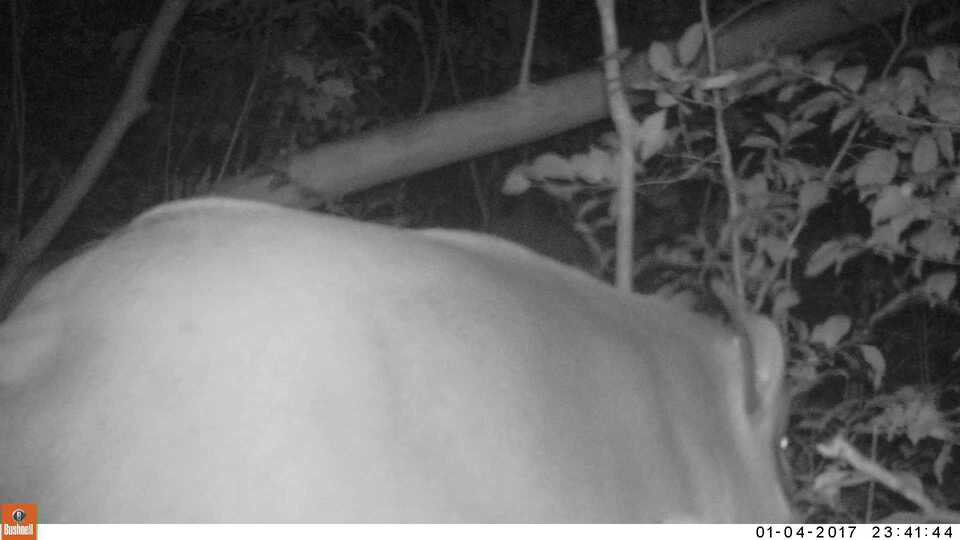

In [9]:
hog_img_pil

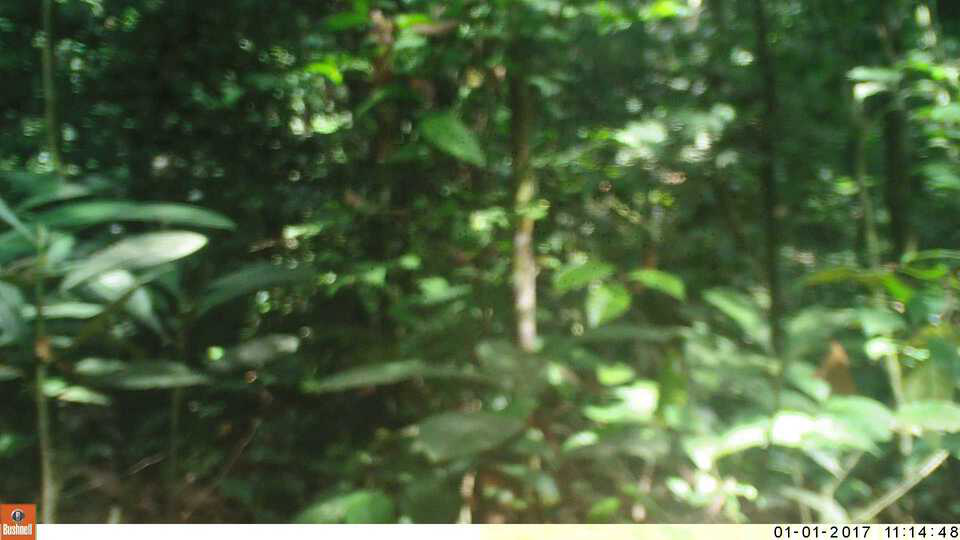

In [10]:
blank_img_pil

In [23]:
# Define transformation to apply to the images
from torchvision import transforms
from PIL import Image

transform = transforms.Compose([
    transforms.Lambda(lambda image: image.convert("RGB")),  # Convert to RGB
    transforms.Resize((224, 224)),  # Resize image
    transforms.ToTensor()  # Convert to tensor
])


print(type(transform))
print(transform)

<class 'torchvision.transforms.transforms.Compose'>
Compose(
    Lambda()
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
)


In [24]:
# Load the dataset using `ImageFolder`
dataset = datasets.ImageFolder(root=train_dir, transform=transform)
print(dataset)

Dataset ImageFolder
    Number of datapoints: 3191
    Root location: C:\Users\GILBERT\Desktop\Binary_classification\data_p1\data_binary\train
    StandardTransform
Transform: Compose(
               Lambda()
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )


In [25]:
im = dataset.imgs
print(im[0])

distinct_classes = {x[1] for x in im}
print(distinct_classes)

('C:\\Users\\GILBERT\\Desktop\\Binary_classification\\data_p1\\data_binary\\train\\blank\\ZJ000013.jpg', 0)
{0, 1}


In [26]:
# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)

train_dataset, val_dataset = random_split(dataset, [0.8, 0.2], generator=g)

In [27]:
print(f"Length of training set: {len(train_dataset)}")


Length of training set: 2553


In [28]:
def class_counts(dataset):
    c = Counter(x[1] for x in tqdm(dataset))
    class_to_index = dataset.dataset.class_to_idx
    return pd.Series({cat: c[idx] for cat, idx in class_to_index.items()})

In [29]:
train_counts = class_counts(train_dataset)
train_counts

  0%|          | 0/2553 [00:00<?, ?it/s]

blank    1749
hog       804
dtype: int64

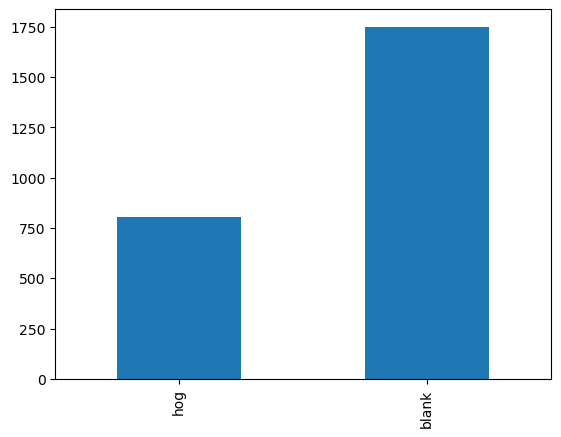

In [30]:
train_counts.sort_values().plot(kind="bar");

  0%|          | 0/638 [00:00<?, ?it/s]

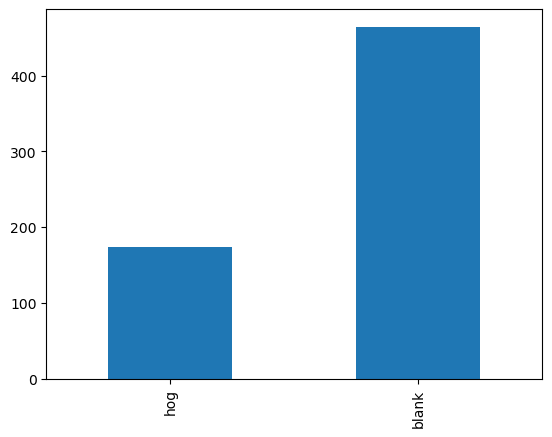

In [31]:
val_counts = class_counts(val_dataset)

# Make a bar chart from the function output
val_counts.sort_values().plot(kind="bar");

In [32]:
# Important, don't change this!
g = torch.Generator()
g.manual_seed(42)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=g)

val_loader = DataLoader(val_dataset, batch_size, shuffle=False)

print(type(val_loader))

<class 'torch.utils.data.dataloader.DataLoader'>


In [33]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

# This gives you [batch_size, channels, height, width] for images
image_shape = images.shape
print("Shape of batch of images", image_shape)

# This gives you [batch_size] for labels
label_shape = labels.shape
print("Shape of batch of labels:", label_shape)

Shape of batch of images torch.Size([32, 3, 224, 224])
Shape of batch of labels: torch.Size([32])


In [34]:
labels

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
        1, 0, 0, 0, 1, 0, 0, 1])

In [35]:
# Building a Shallow Neural Network

In [36]:
flatten = nn.Flatten()
tensor_flatten = flatten(images)

# Print the shape of the flattened tensor
print(tensor_flatten.shape)

torch.Size([32, 150528])


In [37]:
# Image size from our transformer
height = 224
width = 224

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * height * width, 512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.ReLU(),
)

print("model type:", type(model))
print("model structure:")
print(model)

model type: <class 'torch.nn.modules.container.Sequential'>
model structure:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=150528, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
)


In [39]:
output_layer = ...
model.append(output_layer)

print(model)

TypeError: ellipsis is not a Module subclass

In [40]:
model.to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=150528, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=128, bias=True)
  (4): ReLU()
)


In [41]:
summary(model, input_size=(batch_size, 3, height, width))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [32, 128]                 --
├─Flatten: 1-1                           [32, 150528]              --
├─Linear: 1-2                            [32, 512]                 77,070,848
├─ReLU: 1-3                              [32, 512]                 --
├─Linear: 1-4                            [32, 128]                 65,664
├─ReLU: 1-5                              [32, 128]                 --
Total params: 77,136,512
Trainable params: 77,136,512
Non-trainable params: 0
Total mult-adds (G): 2.47
Input size (MB): 19.27
Forward/backward pass size (MB): 0.16
Params size (MB): 308.55
Estimated Total Size (MB): 327.98

In [42]:
loss_fn = nn.CrossEntropyLoss()

In [43]:
# Define an optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [44]:
def train_epoch(model, optimizer, loss_fn, data_loader, device="cpu"):
    # We'll report the loss function's average value at the end of the epoch.
    training_loss = 0.0

    # The train method simply sets the model in training mode. No training
    # has happened.
    model.train()

    # We iterate over all batches in the training set to complete one epoch
    for inputs, targets in tqdm(data_loader, desc="Training", leave=False):
        # Sets the gradients to zero. We need to do this every time.
        optimizer.zero_grad()

        # Unpack images (X) and labels (y) from the batch and add those
        # tensors to the specified device.
        inputs = inputs.to(device)
        targets = targets.to(device)

        # We make a forward pass through the network and obtain the logits.
        # With the logits, we can calculate our loss.
        output = model(inputs)
        loss = loss_fn(output, targets)

        # After calculating our loss, we calculate the numerical value of
        # the derivative of our loss function with respect to all the
        # trainable model weights. Once we have the gradients calculated,
        # we let the optimizer take a "step", in other words, update or
        # adjust the model weights.
        loss.backward()
        optimizer.step()

        # We increment the training loss for the current batch
        training_loss += loss.data.item() * inputs.size(0)

    # We calculate the training loss over the completed epoch
    return training_loss / len(data_loader.dataset)

In [45]:
loss_value = train_epoch(model, optimizer, loss_fn, train_loader, device)
print(f"The average loss during the training epoch was {loss_value:.2f}.")

Training:   0%|          | 0/80 [00:00<?, ?it/s]

The average loss during the training epoch was 15.85.


In [46]:
loss_value = train_epoch(model, optimizer, loss_fn, train_loader, device)
print(f"The average loss during the training epoch was {loss_value:.2f}.")

Training:   0%|          | 0/80 [00:00<?, ?it/s]

The average loss during the training epoch was 2.89.


In [47]:
def predict(model, data_loader, device="cpu"):
    # This tensor will store all of the predictions.
    all_probs = torch.tensor([]).to(device)

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():

        # Again, we iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Predicting", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # The model produces the logits.  This softmax function turns the
            # logits into probabilities.  These probabilities are concatenated
            # into the `all_probs` tensor.
            probs = F.softmax(output, dim=1)
            all_probs = torch.cat((all_probs, probs), dim=0)

    return all_probs

In [48]:
probabilities_train = predict(model, train_loader, device)
print(probabilities_train.shape)

Predicting:   0%|          | 0/80 [00:00<?, ?it/s]

torch.Size([2553, 128])


In [49]:
len(train_loader.dataset)

2553

In [50]:
probabilities_val = predict(model, val_loader, device)
print(probabilities_val.shape)

Predicting:   0%|          | 0/20 [00:00<?, ?it/s]

torch.Size([638, 128])


In [51]:
print(probabilities_train[0])

tensor([1.1040e-08, 1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
        0.0000e+00, 0.0000e+00, 0.0000e+

In [52]:
probabilities_train[0].sum()

tensor(1.)

In [55]:
# Print the probabilities of the first row
print(probabilities_val[0])

tensor([0.5358, 0.4642, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [56]:
total_probability = probabilities_val[0].sum()
print(f"Sum of probabilities: {total_probability.item()}")

Sum of probabilities: 1.0


In [57]:
predictions_train = torch.argmax(probabilities_train, dim=1)

print(f"Predictions shape: {predictions_train.shape}")
print(f"First 10 predictions: {predictions_train[:10]}")

Predictions shape: torch.Size([2553])
First 10 predictions: tensor([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [58]:
predictions_val = torch.argmax(probabilities_val, dim=1)
print(f"Predictions shape: {predictions_val.shape}")
print(f"First 10 predictions: {predictions_val[:10]}")

Predictions shape: torch.Size([638])
First 10 predictions: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])


In [59]:
targets_train = torch.cat([labels for _, labels in train_loader]).to(device)
is_correct_train = torch.eq(predictions_train, targets_train)
total_correct_train = torch.sum(is_correct_train).item()
accuracy_train = total_correct_train / len(train_loader.dataset)

print(f"Accuracy on the training data: {accuracy_train}")

Accuracy on the training data: 0.6192714453584018


In [60]:
targets_val = torch.cat([labels for _,labels in val_loader]).to(device)
is_correct_val = torch.eq(predictions_val, targets_val)
total_correct_val = torch.sum(is_correct_val).item()
accuracy_val = total_correct_val/len(val_loader)

print(f"Accuracy on the validation data: {accuracy_val}")

Accuracy on the validation data: 25.95


In [61]:
def score(model, data_loader, loss_fn, device="cpu"):
    # Initialize the total loss (cross entropy) and the number of correct
    # predictions. We'll increment these values as we loop through the
    # data.
    total_loss = 0
    total_correct = 0

    # We set the model to evaluation mode. This mode is the opposite of
    # train mode we set in the train_epoch function.
    model.eval()

    # Since we're not training, we don't need any gradient calculations.
    # This tells PyTorch not to calculate any gradients, which speeds up
    # some calculations.
    with torch.no_grad():
        # We iterate over the batches in the data loader and feed
        # them into the model for the forward pass.
        for inputs, targets in tqdm(data_loader, desc="Scoring", leave=False):
            inputs = inputs.to(device)
            output = model(inputs)

            # Calculating the loss function for this batch
            targets = targets.to(device)
            loss = loss_fn(output, targets)
            total_loss += loss.data.item() * inputs.size(0)

            # Calculating the correct predictions for this batch
            correct = torch.eq(torch.argmax(output, dim=1), targets)
            total_correct += torch.sum(correct).item()

    return total_loss / len(data_loader.dataset), total_correct / len(
        data_loader.dataset
    )

In [62]:
loss_train, accuracy_train = score(model, train_loader, loss_fn, device)
print(f"Training accuracy from score function: {accuracy_train}")

Scoring:   0%|          | 0/80 [00:00<?, ?it/s]

Training accuracy from score function: 0.81825303564434


In [63]:
loss_val, accuracy_val = score(model, val_loader, loss_fn, device)
print(f"Validation accuracy from score function: {accuracy_val}")

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Validation accuracy from score function: 0.8134796238244514


In [64]:
def train(model, optimizer, loss_fn, train_loader, val_loader, epochs=20, device="cpu"):

    for epoch in range(1, epochs + 1):
        # Run train_epoch once, and capture the training loss.
        training_loss = train_epoch(model, optimizer, loss_fn, train_loader, device)

        # Score the model on the validation data.
        validation_loss, validation_accuracy = score(model, val_loader, loss_fn, device)

        print(
            f"Epoch: {epoch}, Training Loss: {training_loss:.2f}, "
            f"Validation Loss: {validation_loss:.2f}, Validation Accuracy: {validation_accuracy:.2f}"
        )

In [67]:
train(model, optimizer, loss_fn, train_loader, val_loader, epochs=5, device=device)

Training:   0%|          | 0/80 [00:00<?, ?it/s]

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.42, Validation Loss: 0.51, Validation Accuracy: 0.84


Training:   0%|          | 0/80 [00:00<?, ?it/s]

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

...

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 4, Training Loss: 0.32, Validation Loss: 0.24, Validation Accuracy: 0.91


Training:   0%|          | 0/80 [00:00<?, ?it/s]

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 5, Training Loss: 0.28, Validation Loss: 0.26, Validation Accuracy: 0.90


In [66]:

train(model, optimizer, loss_fn, train_loader, val_loader, epochs=2,device=device)

Training:   0%|          | 0/80 [00:00<?, ?it/s]

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1, Training Loss: 0.32, Validation Loss: 0.25, Validation Accuracy: 0.91


Training:   0%|          | 0/80 [00:00<?, ?it/s]

Scoring:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 2, Training Loss: 0.42, Validation Loss: 0.25, Validation Accuracy: 0.92


In [68]:
model = torch.load("model/trained_model.pth", weights_only=False)

FileNotFoundError: [Errno 2] No such file or directory: 'model/trained_model.pth'

In [70]:
probabilities_val = predict(model, val_loader, device)
predictions_val = torch.argmax(probabilities_val, dim=1)
print(predictions_val[:10])

Predicting:   0%|          | 0/20 [00:00<?, ?it/s]

tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])


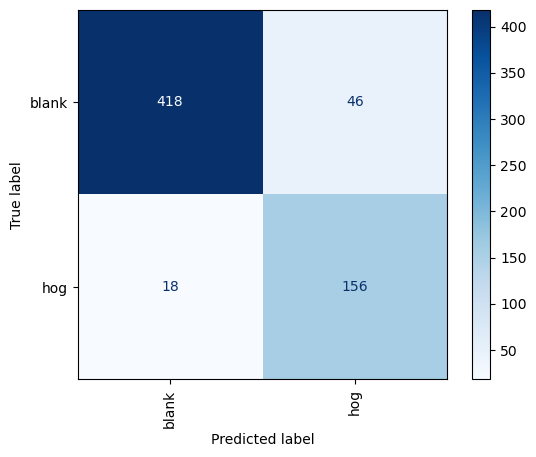

In [71]:
cm = confusion_matrix(targets_val.cpu(), predictions_val.cpu())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["blank", "hog"])

disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical");

In [72]:
img_path = os.path.join(data_dir, "train/hog/ZJ000072.jpg")

NameError: name 'data_dir' is not defined

In [ ]:
from IPython.display import Image as JupyterImage
JupyterImage(filename=img_path) 

In [73]:
labels = ["blank", "hog"]

img = Image.open(os.path.join(data_dir, "train/hog/ZJ000072.jpg"))
img = transform(img).to(device)
img = torch.unsqueeze(img, 0)

model.eval()
prediction = F.softmax(model(img), dim=1)
prediction = prediction.argmax()
print(labels[prediction])

NameError: name 'data_dir' is not defined

In [74]:
F.softmax(model(img), dim=1)

NameError: name 'img' is not defined

In [75]:
torch.save(model, os.path.join("model", "shallownet"))

RuntimeError: Parent directory model does not exist.

In [76]:
torch.save(model.state_dict(), os.path.join("model", "shallownet"))
new_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(3 * height * width, 512),
    nn.ReLU(),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Linear(128, 2),
)
model_state_dict = torch.load(os.path.join("model", "shallownet"))
new_model.load_state_dict(model_state_dict)

RuntimeError: Parent directory model does not exist.